<a href="https://colab.research.google.com/github/swiz9/Flight-Delay-Prediction-System/blob/lstm-model/LSTM_Prediction_Model_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Define the path to the data set
path = "/content/drive/MyDrive/flights_sample_3m.zip"

In [6]:
# importing the dataset
df = pd.read_csv(path)

# checking the dataset
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


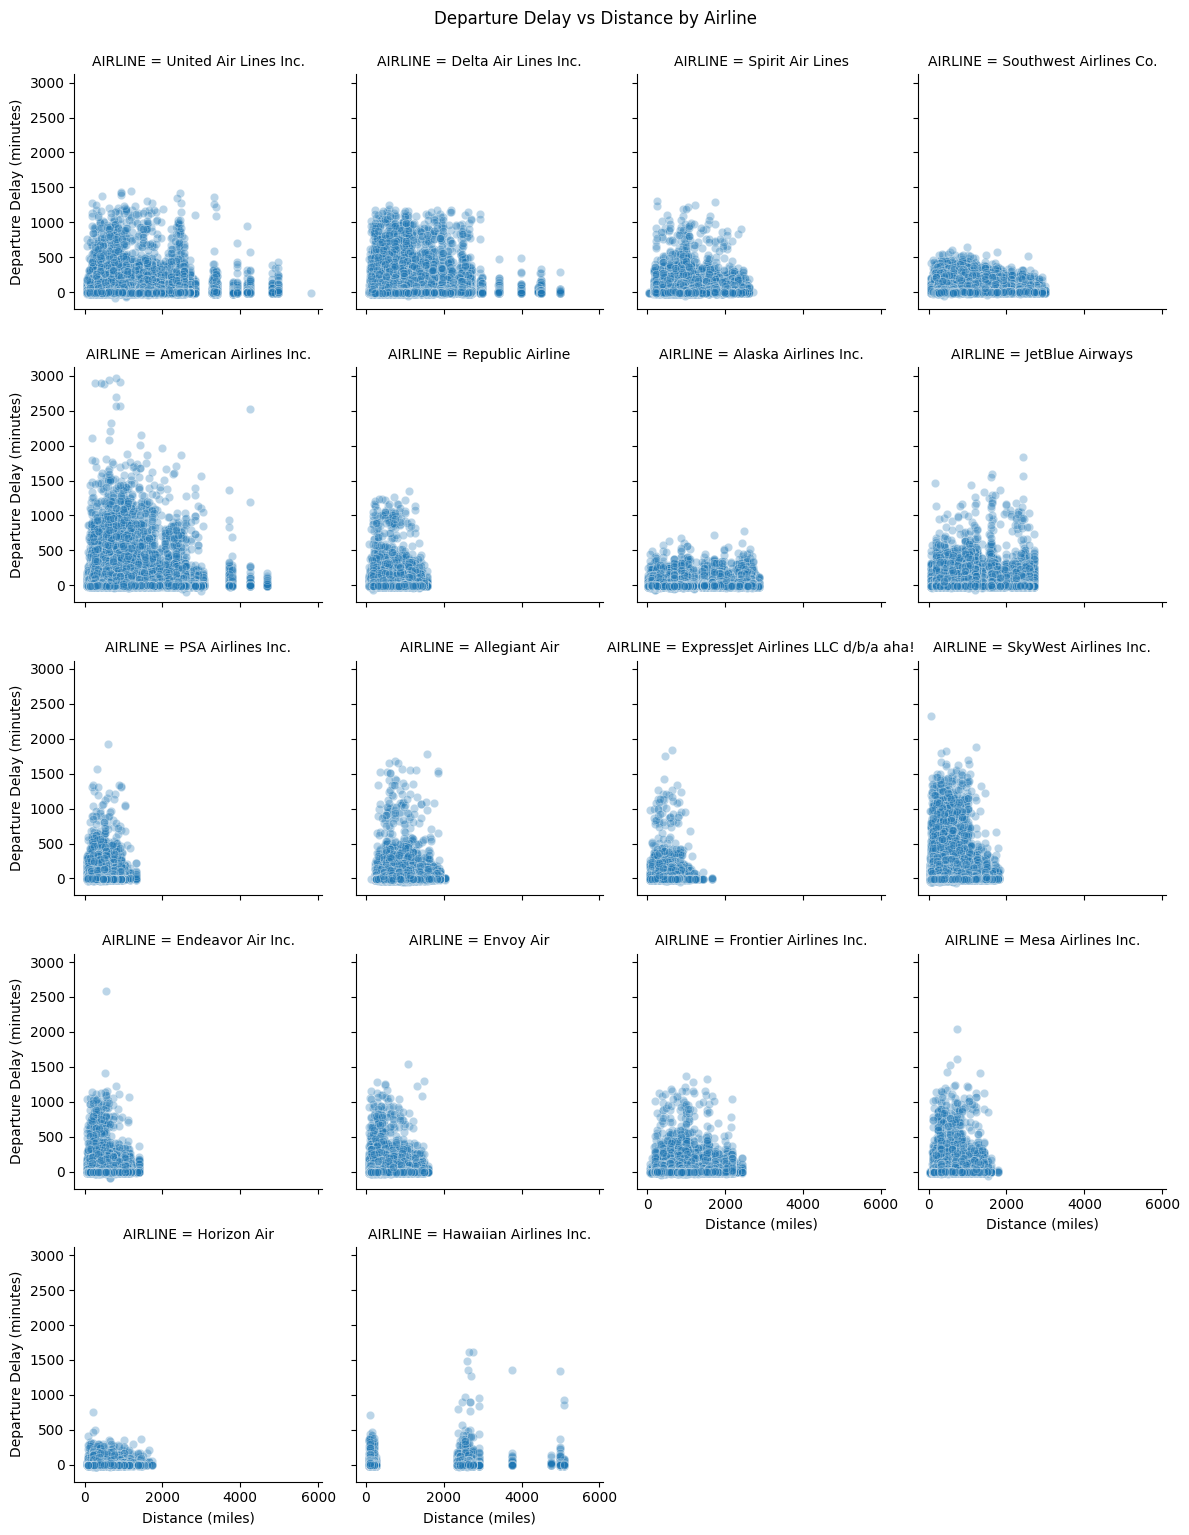

In [7]:
#Add FacetGrid visualization for departure delay vs distance by airline
g = sns.FacetGrid(df, col="AIRLINE", col_wrap=4)
g.map(sns.scatterplot, 'DISTANCE', 'DEP_DELAY', alpha=0.3)
g.set_axis_labels('Distance (miles)', 'Departure Delay (minutes)')
g.fig.suptitle('Departure Delay vs Distance by Airline', y=1.02)
plt.show()

In [8]:
#Filter dataset to remove flights with non-positive arrival delays
df = df[df['ARR_DELAY'] > 0]
print(df['ARR_DELAY'])

3           24.0
5          141.0
7           23.0
9            1.0
10          60.0
           ...  
2999981     16.0
2999982     21.0
2999988    214.0
2999990     13.0
2999997     36.0
Name: ARR_DELAY, Length: 978147, dtype: float64


In [9]:
# show the shape of the dataset and the number of rows and columns
df.shape

(978147, 32)

In [10]:
# check the data types of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 978147 entries, 3 to 2999997
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  978147 non-null  object 
 1   AIRLINE                  978147 non-null  object 
 2   AIRLINE_DOT              978147 non-null  object 
 3   AIRLINE_CODE             978147 non-null  object 
 4   DOT_CODE                 978147 non-null  int64  
 5   FL_NUMBER                978147 non-null  int64  
 6   ORIGIN                   978147 non-null  object 
 7   ORIGIN_CITY              978147 non-null  object 
 8   DEST                     978147 non-null  object 
 9   DEST_CITY                978147 non-null  object 
 10  CRS_DEP_TIME             978147 non-null  int64  
 11  DEP_TIME                 978147 non-null  float64
 12  DEP_DELAY                978147 non-null  float64
 13  TAXI_OUT                 978147 non-null  float64
 14  WHEELS_O

In [11]:
#function for extract new hours and min from time features
def process_time_columns(df):
    # Convert 'hhmm' format into 'hours' and 'minutes' for both CRS_DEP_TIME and CRS_ARR_TIME
    df['CRS_DEP_HOUR'] = df['CRS_DEP_TIME'] // 100  # Extract hour part
    df['CRS_DEP_MINUTE'] = df['CRS_DEP_TIME'] % 100  # Extract minute part
    df['CRS_ARR_HOUR'] = df['CRS_ARR_TIME'] // 100  # Extract hour part
    df['CRS_ARR_MINUTE'] = df['CRS_ARR_TIME'] % 100  # Extract minute part

    # create a time period (morning, afternoon, etc.)
    df['DEP_TIME_PERIOD'] = pd.cut(df['CRS_DEP_HOUR'], bins=[0, 6, 12, 18, 24],
                                   labels=['Night', 'Morning', 'Afternoon', 'Evening'], right=False)
    return df

In [12]:
#function for extract new features
def process_flight_data(df):
    df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')  # Auto-infer format

    # Extract relevant date features
    df['DayOfWeek'] = df['FL_DATE'].dt.weekday  # 0=Monday, 6=Sunday
    df['IsWeekend'] = df['DayOfWeek'] >= 5  # True if weekend (Saturday/Sunday)

    # Process the time columns (CRS_DEP_TIME, CRS_ARR_TIME)
    df = process_time_columns(df)

    return df


In [13]:
#function calling for process_flight_data
df = process_flight_data(df)

/tmp/ipython-input-4190748991.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], errors='coerce')  # Auto-infer format
/tmp/ipython-input-4190748991.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DayOfWeek'] = df['FL_DATE'].dt.weekday  # 0=Monday, 6=Sunday
/tmp/ipython-input-4190748991.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

In [14]:
#define arry of removing feature
columns_to_drop = [
    'CANCELLED',
    'CANCELLATION_CODE',
    'TAXI_OUT',
    'WHEELS_OFF',
    'WHEELS_ON',
    'TAXI_IN',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT',
    'DOT_CODE',
    'AIRLINE_CODE',
    'ORIGIN_CITY' ,
    'DEST_CITY',
    'AIRLINE_DOT',
    'FL_NUMBER',
    'DIVERTED',
    'FL_DATE'
]

In [ ]:
#function for encode categorical data
le = LabelEncoder()

def clean_labels_encoder(list_of_labels, df):
    for label in list_of_labels:
        df[label] = le.fit_transform(df[label])
    return df
